**INTRODUCTION**

**Netflix** is a streaming platform where people can watch movies, TV shows anytime over the internet.

In this project, I will be working on the **Netflix Titles** dataset to understand and analyze the content available on the platform. This dataset includes information about movies and TV shows on Netflix, and through this analysis, I will try to find useful insights and observe trends in the data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv("/content/netflix_titles.csv")


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8802,False
8803,False
8804,False
8805,False


**Dataset Overview Summery**

This dataframe has 8807 rows and 12 columns.

We have 4303 missing values in this dataset most of them are from
Director - 2634 missing values.

Date_Added is in string and has to be in DateTime.

Most of the columns in the dataset are of object type (categorical data), while only the release_year column is numerical.

The content in the dataset was released between 1925 and 2021, with the average year being around 2014. Most of the titles are from the period between 2013 and 2019, which shows that Netflix mainly has more recent movies and TV shows compared to older ones.




**DATA CLEANING**


So we had seen so many missing values in many columns.
Now I am going fill that with suitable values.

In [ ]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

# IN these columns I filled null values with "Unknown" because of so many null values were there.

In [ ]:
# Now date_added in an object so i have to change its datatype to datetime.

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

# Now filling null values in date_added.

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])


df['date_added'].dtype


dtype('<M8[ns]')

In [ ]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

In [ ]:
# Now two more columns remaining Rating and Duration

# And here i have transfered Rating Data to duration

df.loc[df['show_id'] == 's5542', 'duration'] = df.loc[df['show_id'] == 's5542', 'rating']
df.loc[df['show_id'] == 's5795', 'duration'] = df.loc[df['show_id'] == 's5795', 'rating']
df.loc[df['show_id'] == 's5814', 'duration'] = df.loc[df['show_id'] == 's5814', 'rating']



In [ ]:
# Now changing duration column object to numeric ( Removing "min").

df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)


In [ ]:
# Now in Rating column where null value presented , I have entered correct data from google.

df.loc[df['rating']== '74 min'] = 'TV-14'
df.loc[df['rating']== '84 min'] = 'TV-PG'
df.loc[df['rating']== '66 min'] = 'PG-13'
df.loc[df['rating']== '74 min'] = 'PG-13'


/tmp/ipykernel_3111/1541264477.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TV-14' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[df['rating']== '74 min'] = 'TV-14'
/tmp/ipykernel_3111/1541264477.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TV-14' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['rating']== '74 min'] = 'TV-14'
/tmp/ipykernel_3111/1541264477.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TV-14' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['rating']== '74 min'] = 'TV-14'


In [ ]:
# There are many genres in column listed_in , so we need to clean this and take only first genres.

df['listed_in'] = df['listed_in'].astype(str)
df['listed_in'] = df['listed_in'].str.split(',').str[0].str.strip()

In [ ]:
df['listed_in']

,listed_in
0,Documentaries
1,International TV Shows
2,Crime TV Shows
3,Docuseries
4,International TV Shows
...,...
8802,Cult Movies
8803,Kids' TV
8804,Comedies
8805,Children & Family Movies


In [ ]:
# No null value in here now we are good to go.

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,0


**Work I have done to perform Data Cleaning.**

In this step, the dataset was cleaned to make it suitable for analysis. Missing values in columns like director, cast, and country were filled with “Unknown” to avoid losing data. The date_added column was converted into datetime format, and its missing values were filled using the most frequent date.

Some inconsistencies were found between the rating and duration columns, where values were placed incorrectly. These were corrected, and the duration column was cleaned by extracting only numerical values. Missing values in the rating column were also updated with correct information.

The listed_in column contained multiple genres, so only the primary genre was extracted to simplify analysis. After these steps, the dataset was checked to ensure there were no missing values left.



**EXPLORATORY DATA ANALYSIS**

**Overall, the dataset is now clean, structured, and ready for further analysis and visualization.**

In [ ]:
# To make EDA part little easy and visualization simple. I am extracting Month and Year from date_added columns
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

**Data Visualization - Part 1:**

Create visualizations to represent the distribution of content over different genres.

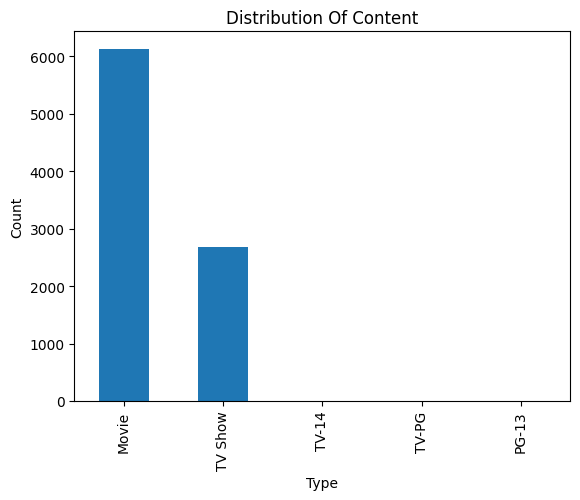

In [ ]:
df['type'].value_counts().plot(kind='bar')
plt.title("Distribution Of Content")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Movies dominate Netflix content
# TV Shows are fewer but growing

**Data Visualization - Part 2:**

Visualize the distribution of content across release years.

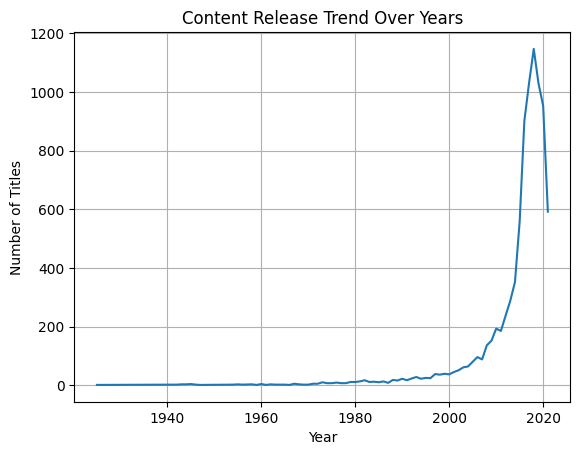

In [ ]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title('Content Release Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid()
plt.show()

# I used line chart because A line chart is used to visualize trends in content release over time, making it easier to identify growth patterns and peak years.

# Rapid growth after 2016
# Peak around 2019–2020
# Shows Netflix expansion phase

**Data Visualization - Part 3:**

Explore the geographical distribution of content (if applicable).

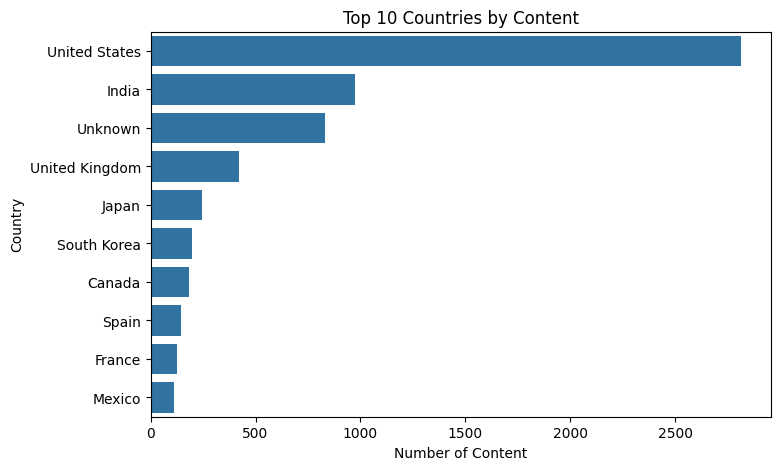

In [ ]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries by Content")
plt.xlabel("Number of Content")
plt.ylabel("Country")

plt.show()

#I used a horizontal bar chart because it improves readability when comparing multiple categories with long labels like country names.


**Time Series Analysis:**

If there's a temporal component, perform time series analysis to identify trends and patterns over
time.

In [ ]:
# Year Wise Trends Analysis.

year_trend = df['year_added'].value_counts().sort_index()

fig = px.line(
    x=year_trend.index,
    y=year_trend.values,
    title='Year-wise Content Addition Trend',
    labels={'x': 'Year', 'y': 'Number of Titles'},
    width=700,
    height=400
)

fig.show()


In [ ]:
# Month Wise Trends Analysis.
month_trend = df['month_added'].value_counts().sort_index()
fig = px.line(
    x=month_trend.index,
    y= month_trend.values,
    title = "Month - wise content Addition Trend",
    labels= {'x':'Month', 'Y':'Number of titles'},
    width = 700,
    height=400)

fig.show()


**Content Analysis - Part 1:**

Analyze the distribution of content ratings.

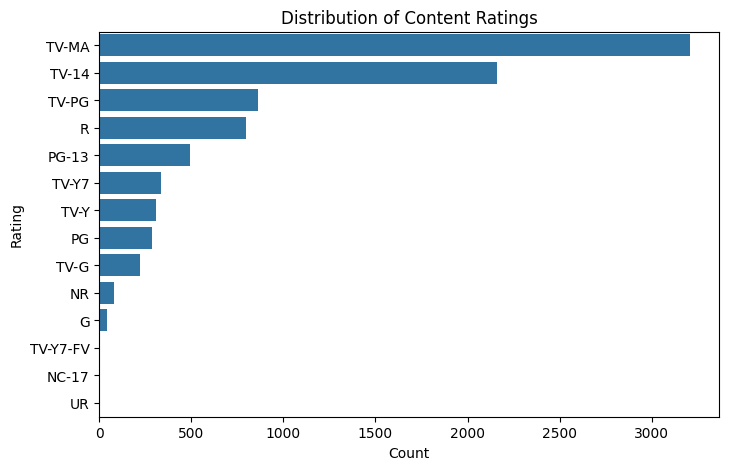

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index
)

plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()


# Key Insights -
# Most content falls under TV-MA and TV-14
# Indicates strong focus on adult and teenage audiences
# Limited content is available for children (e.g., G, PG ratings)

**Content Analysis - Part 2:**

Explore the length of movies or episodes and identify any trends.

In [ ]:
# Separate datasets
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

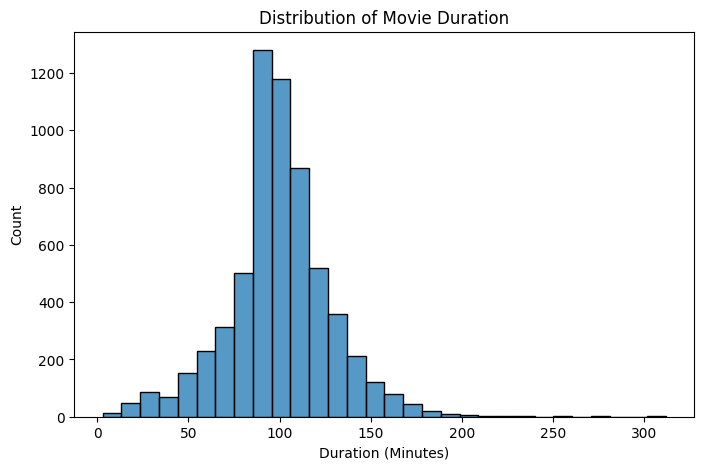

In [ ]:
# Movie Duration Analysis
plt.figure(figsize=(8,5))

sns.histplot(movies['duration_num'], bins=30)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')

plt.show()

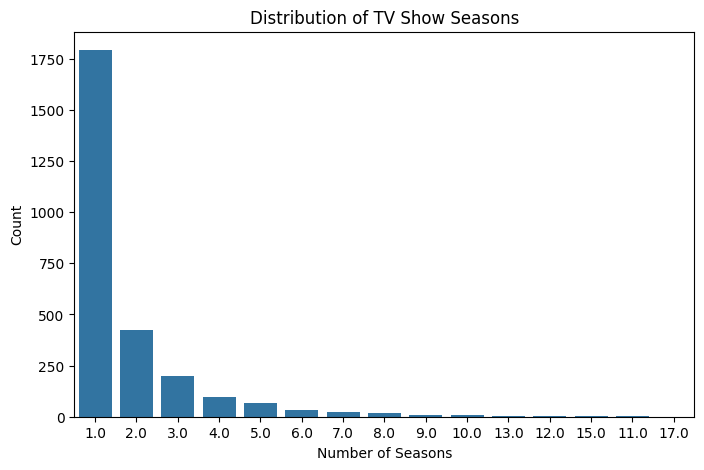

In [ ]:
# TV Show Duration Analysis
plt.figure(figsize=(8,5))

sns.countplot(
    x=tv_shows['duration_num'],
    order=tv_shows['duration_num'].value_counts().index
)

plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')

plt.show()

**Top Lists and Recommendations:**

Identify and present top-rated movies or TV shows based on user ratings.

In [ ]:
# Top Movies by Rating Category

top_movies = df[df['type'] == 'Movie']
top_movies_rating = top_movies['rating'].value_counts().head(5)


# Top TV Shows by Rating Category
Top_Show = df[df['type'] == 'Movie']
Top_Show_Rating = Top_Show['rating'].value_counts().head(5)


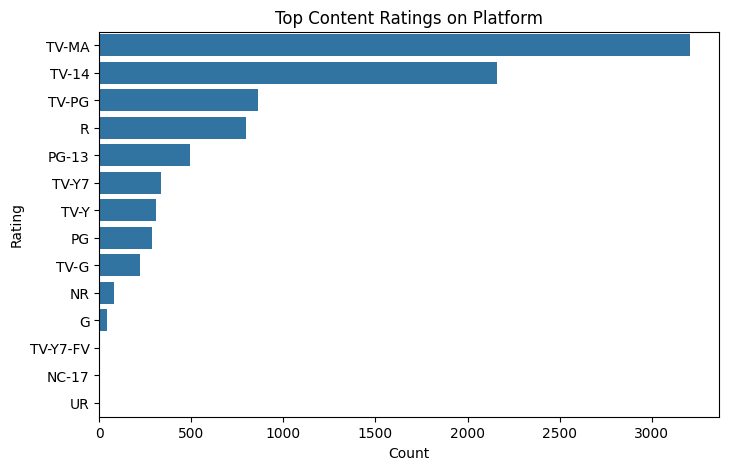

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index
)

plt.title('Top Content Ratings on Platform')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

# Key Insights
# TV-MA and TV-14 are the most common ratings
# Indicates strong focus on adult and teenage audience
# Movies and TV shows both follow similar rating distribution

**Genre Trends:**

Analyze trends in the popularity of different genres over time.

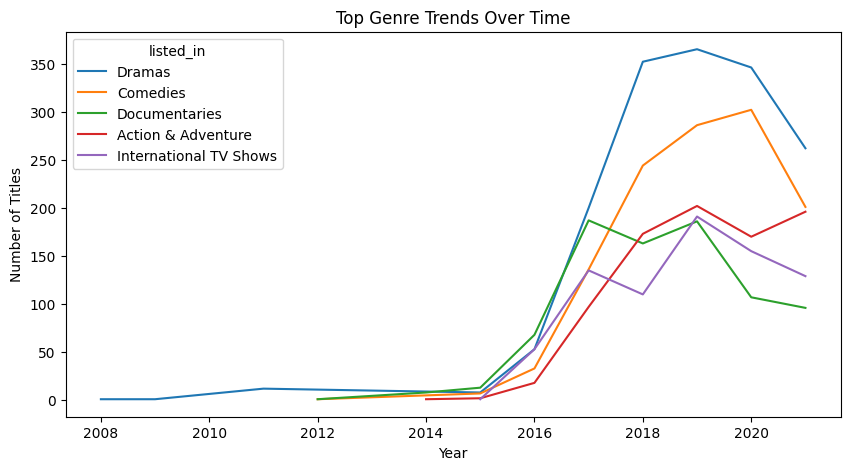

In [ ]:
top_genres = df['listed_in'].value_counts().head(5).index

genre_over_time = df[df['listed_in'].isin(top_genres)].groupby(['year_added', 'listed_in']).size().reset_index(name='count')

plt.figure(figsize=(10,5))

sns.lineplot(
    data=genre_over_time,
    x='year_added',
    y='count',
    hue = 'listed_in'
)

plt.title('Top Genre Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

# Key Insights
# Genres like Dramas, Comedies, and Documentaries dominate the platform
# There is a noticeable increase in all major genres after 2018
# Some genres show steady growth, while others fluctuate over time

**Geographical Analysis:**

Further explore the distribution of content across different countries and regions.

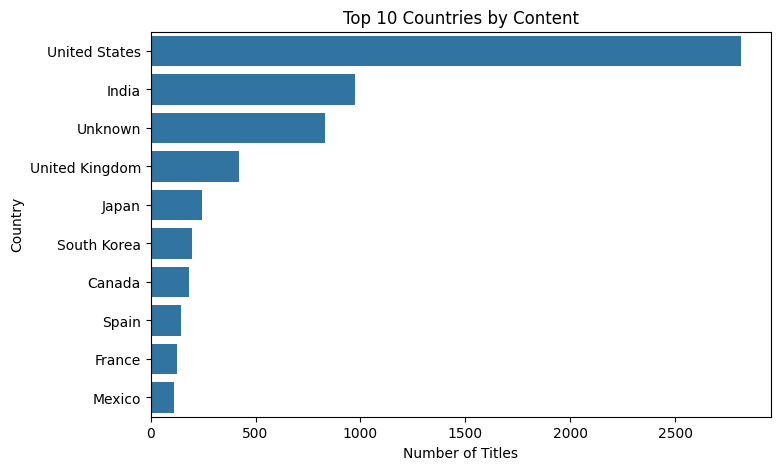

In [ ]:
df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title('Top 10 Countries by Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()


# Key Insights
# The United States has the highest number of titles
# Other major contributors include India, United Kingdom, and Canada
# Content is distributed globally, showing Netflix’s international reach
# Both Movies and TV Shows are widely produced across top countries

**Correlation Analysis:**

Investigate potential correlations between variables (e.g., ratings and duration).

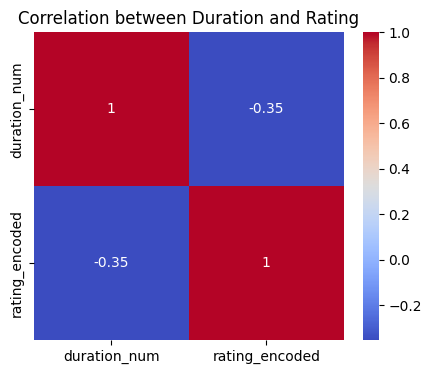

In [ ]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['rating_encoded'] = df['rating'].astype('category').cat.codes
corr = df[['duration_num', 'rating_encoded']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation between Duration and Rating')

plt.show()

# Key Insights
# The correlation value is usually close to 0
# This indicates no strong relationship between duration and rating
# Content length does not significantly influence its rating category

**Audience Engagement - Part 1:**

Analyze user reviews and sentiments if available.

In [ ]:
# The Netflix dataset used in this project does not contain user reviews or textual feedback.

**Audience Engagement - Part 2:**

Explore user engagement metrics such as views or watch time (if applicable).

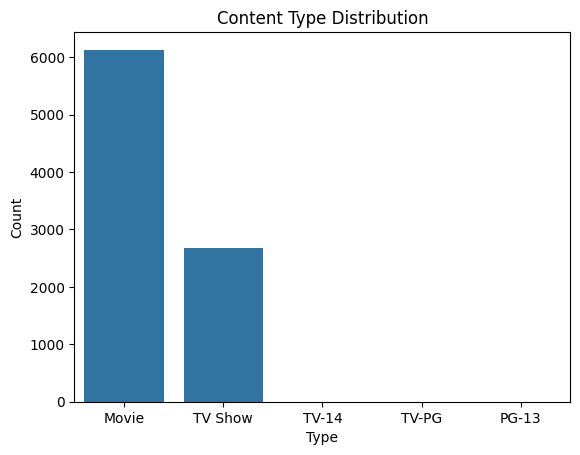

In [ ]:
sns.countplot(x=df['type'])

plt.title('Content Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

# Higher number of Movies or TV Shows indicates platform strategy
# TV Shows often lead to higher engagement due to multiple episodes

**Content Variety:**

Evaluate the diversity of content by analyzing the number of unique genres and categories.

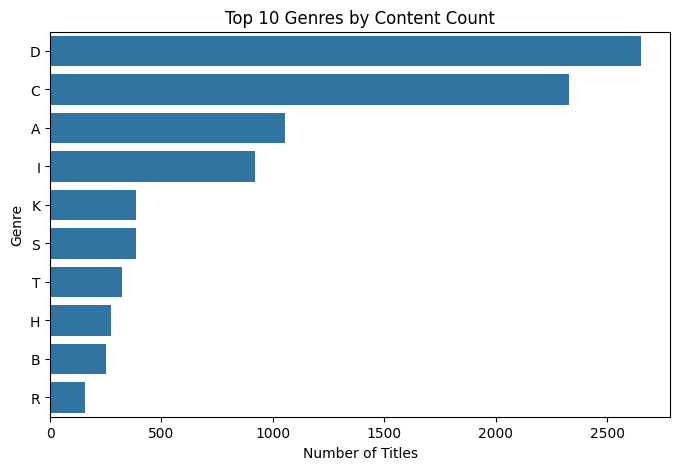

In [ ]:
top_genres = df['listed_in'].str[0].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title('Top 10 Genres by Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

# The platform offers a wide variety of genres, indicating high content diversity
# Genres like Dramas, Comedies, and Documentaries are most common
# Presence of multiple categories per title increases overall variety
# Both Movies and TV Shows contribute to content diversity


**Language Analysis:**

If applicable, analyze the distribution of content in different languages.

In [ ]:
# The dataset does not have a direct language column.

**Content Evolution Over Time:**

Explore how the characteristics of content (e.g., duration, ratings) have evolved over the
years.

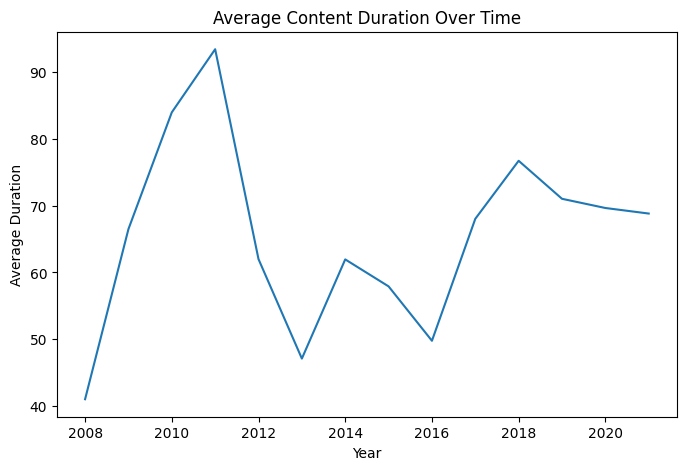

In [ ]:
duration_trend = df.groupby('year_added')['duration_num'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(data=duration_trend, x='year_added', y='duration_num')

plt.title('Average Content Duration Over Time')
plt.xlabel('Year')
plt.ylabel('Average Duration')

plt.show()

# Average duration remains relatively stable
# Slight variations indicate changing content formats

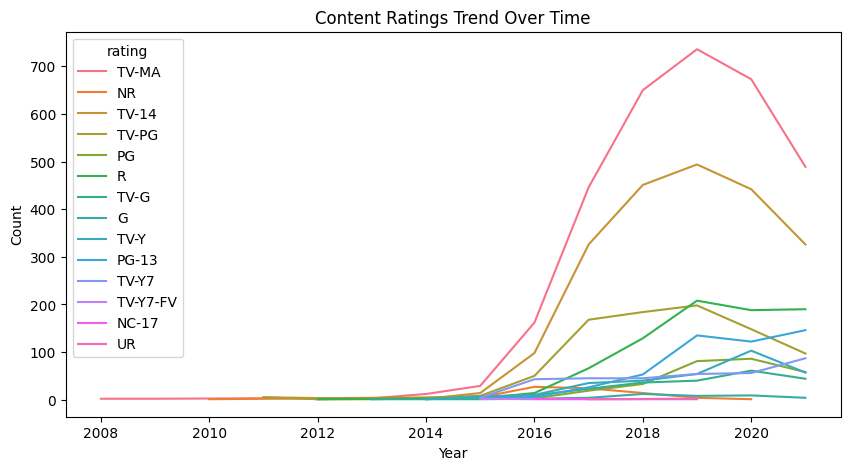

In [ ]:
rating_trend = df.groupby(['year_added', 'rating']).size().reset_index(name='count')

plt.figure(figsize=(10,5))

sns.lineplot(
    data=rating_trend,
    x='year_added',
    y='count',
    hue='rating'
)

plt.title('Content Ratings Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

# Content volume has increased significantly in recent years
# Average duration shows minor variation over time
# Strong growth in mature-rated content
# Platform strategy is evolving towards diverse and binge-worthy content

**User Preferences:**

Investigate whether certain genres or types of content are more popular among users.

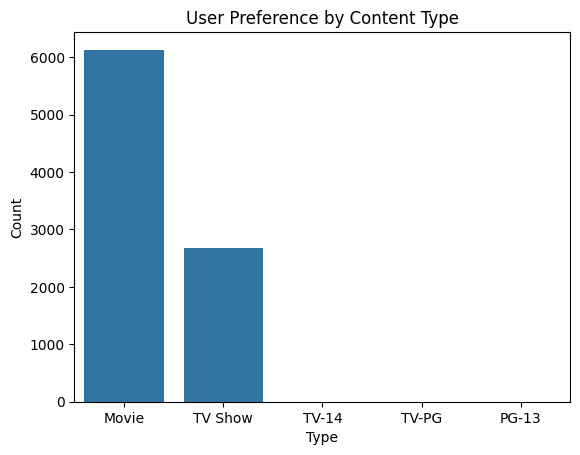

In [ ]:
# The dataset does not contain direct user interaction data (likes, views, watch history).
# Therefore, popularity is inferred using:
# Frequency of genres
# Content type distribution
# Ratings

sns.countplot(x=df['type'])

plt.title('User Preference by Content Type')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

# Key Insights
# Users prefer Movies slightly more than TV Shows (based on availability)
# Drama and Comedy are the most popular genres
# Majority of content targets teen and adult audiences
# Platform focuses on binge-worthy and engaging content

**CONCLUSIONS AND RECOMMENDATIONS:**

Summarize the key findings, draw conclusions, and provide recommendations based on
the insights gained from the analysis.


**1. Key Findings**

From the analysis, it can be seen that the platform has grown rapidly over the years, especially after 2018. A large portion of the content consists of movies, although TV shows also play an important role in keeping users engaged for a longer time.

When looking at genres, Drama, Comedy, and Documentaries appear most frequently, showing that these are highly preferred types of content. In terms of ratings, most content falls under TV-MA and TV-14, which suggests that the platform mainly targets teenagers and adult audiences.

It was also observed that countries like the United States and India contribute the most content. Additionally, most movies have a duration between 80 to 120 minutes, which makes them easy to watch and suitable for binge consumption.

**2. Overall Conclusion **

Overall, the platform seems to follow a clear strategy of continuously adding new content while focusing on popular genres and mature audiences. The variety of content available also shows that the platform is trying to serve different types of viewers across the world.

**3. Recommendations**

Based on the analysis, a few improvements can be suggested:

The platform can add more content for children and family audiences to make the library more balanced It can continue investing in popular genres like Drama and Comedy to maintain user interest Expanding content production in different countries and languages can help reach a wider audience More focus on TV shows and series can improve user engagement, as they keep viewers coming back If possible, adding user data like watch time and ratings would help in making better recommendations

**4. Final Statement**

In conclusion, the platform is doing well in terms of growth and content variety. With a few improvements in content diversity and user-based insights, it can further strengthen its position and provide a better experience to users.